# Monte Carlo Option Pricing
This notebook explores option pricing using Monte Carlo simulation, first applied to European call options for comparison with the analytical Black-Scholes benchmark, and later extended to exotic options.

## Introduction

Option pricing models aim to determine the fair value of financial derivatives whose payoffs depend on an underlying asset such as a stock. Under the risk-neutral measure, stock prices are assumed to follow a stochastic process called Geometric Brownian Motion (GBM):

$$
dS_t = r S_t \, dt + \sigma S_t \, dW_t,
$$

where $S_t$ is the stock price at time $t$, $r$ is the risk-free interest rate, $\sigma$ is the volatility, and $W_t$ is a standard Brownian motion.

Both the Black-Scholes model and Monte Carlo simulation are derived from this stochastic process, providing analytical and numerical approaches to option pricing.

In [1]:
import numpy as np
import yfinance as yf
from scipy.special import ndtr
from utils import compute_convergence_prices, plot_convergence, plot_standard_error, plot_standard_error_comparison, plot_up_and_out_call

## Historical Volatility Estimation

Volatility and the spot price are estimated from one year of historical data for Apple (AAPL), chosen as an example underlying asset to ensure realistic parameter values. A fixed one-year time window is used to ensure reproducibility.

In [2]:
# retrieve historical data
apple = yf.Ticker('AAPL')
data = apple.history(start='2024-10-01', end='2025-10-01')
close_prices = data['Close'].copy()
S0 = close_prices.iloc[-1]                      # spot price

# compute historical volatility
log_ret = np.log(close_prices).diff().dropna()  # daily log-returns
sigma_daily = log_ret.std(ddof=1)               # daily volatility
sigma = sigma_daily * np.sqrt(252)              # annualised volatility

print(f'Spot price: {S0:.2f}')
print(f'Volatility: {sigma:.2f}')

Spot price: 254.63
Volatility: 0.32


## Black-Scholes Model

The Black-Scholes model, derived from the GBM process, provides a closed-form analytical solution for the price of a European call option $C_0$:

$$
C_0 = S_0 N(d_1) - K e^{-rT} N(d_2),
$$

where

$$
d_1 = \frac{\ln(S_0/K) + (r + \frac{1}{2} \sigma^2) T}{\sigma \sqrt{T}}, \qquad d_2 = d_1 - \sigma \sqrt{T},
$$

and $S_0$ is the spot price, $K$ is the strike price, $T$ is the time to maturity in years and $N(x)$ is the standard normal cumulative distribution function (CDF).

In [3]:
class BlackScholesPricer:
    def __init__(self, spot_price, strike_price, risk_free_rate, volatility, time_to_maturity):
        self.S = spot_price
        self.K = strike_price
        self.r = risk_free_rate
        self.sigma = volatility
        self.T = time_to_maturity

    def calculate_d1(self):
        num = np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T
        den = self.sigma * np.sqrt(self.T)
        return num / den

    def calculate_d2(self, d1):
        return d1 - self.sigma * np.sqrt(self.T)

    def call_price(self):
        d1 = self.calculate_d1()
        d2 = self.calculate_d2(d1)
        return (self.S * ndtr(d1)) - (self.K * np.exp(-self.r * self.T) * ndtr(d2))

The call price is computed using $T=1$, $K=S_0$, $r=0.05$ and volatility estimated from historical data.

In [4]:
# define parameters for option pricing
K = S0      # strike price
r = 0.05    # risk-free interest rate
T = 1       # time to maturity in years

# create Black-Scholes pricer
bs_pricer = BlackScholesPricer(S0, K, r, sigma, T)

# calculate call option price
call_price_bs = bs_pricer.call_price()

print(f'Black-Scholes Benchmark: {call_price_bs:.2f}')

Black-Scholes Benchmark: 38.36


## Monte Carlo Simulation

Monte Carlo simulation estimates option prices by simulating many possible future stock price paths and averaging the discounted payoffs across all of these. A total of $N$ paths are simulated using the discretised solution of GBM:

$$
S_{t+\Delta t} = S_t \exp \Big( \big(r - \tfrac{1}{2}\sigma^2\big)\Delta t + \sigma \sqrt{\Delta t}\, Z \Big), \qquad Z \sim N(0,1),
$$

where $Z$ is a standard normal random variable.

For a European call option, whose payoff depends only on the terminal price $S_T$, the price $C_0$ is given by

$$
C_0 \approx e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^N \max(S_T^{(i)} - K, 0).
$$

In [5]:
class MonteCarloPricer:
    def __init__(self, spot_price, strike_price, risk_free_rate, volatility, time_to_maturity):
        self.S = spot_price
        self.K = strike_price
        self.r = risk_free_rate
        self.sigma = volatility
        self.T = time_to_maturity

    def calculate_terminal_prices(self, num_simulations):
        drift = (self.r - 0.5 * self.sigma ** 2) * self.T
        vol = self.sigma * np.sqrt(self.T)
        Z = rng.standard_normal(num_simulations)                # generate N random shocks
        return self.S * np.exp(drift + vol * Z)

    def call_price_european(self, num_simulations):
        ST = self.calculate_terminal_prices(num_simulations)
        payoff = np.maximum(ST - self.K, 0)
        discounted = np.exp(-self.r * self.T) * payoff          # discount to present value
        price = discounted.mean()                               # average across all paths
        se = discounted.std(ddof=1) / np.sqrt(num_simulations)  # calculate standard error
        return price, se

    def generate_price_paths(self, num_simulations, num_steps):
        dt = self.T / num_steps                                 # time step in years
        drift = (self.r - 0.5 * self.sigma ** 2) * dt
        vol = self.sigma * np.sqrt(dt)

        paths = np.zeros((num_steps + 1, num_simulations))      # rows: time steps, columns: paths
        paths[0] = self.S                                       # set initial spot price

        for t in range(1, num_steps + 1):
            Z = rng.standard_normal(num_simulations)            # generate N random shocks
            paths[t] = paths[t - 1] * np.exp(drift + vol * Z)

        time = np.linspace(0, self.T, num_steps + 1)

        return paths, time

The call price is computed using the same parameters as the Black-Scholes benchmark, with $N=1000$ simulations.

In [6]:
# global random number generator for reproducibility
rng = np.random.default_rng(seed=42)

# create Monte Carlo pricer
mc_pricer = MonteCarloPricer(S0, K, r, sigma, T)

# estimate call option price using 1000 simulations
call_price_mc, _ = mc_pricer.call_price_european(num_simulations=1000)

print(f'Black-Scholes Benchmark:    {call_price_bs:.2f}')
print(f'Monte Carlo (N=1000):       {call_price_mc:.2f}')

Black-Scholes Benchmark:    38.36
Monte Carlo (N=1000):       35.97


## Convergence to Black-Scholes

The Monte Carlo estimate differs slightly from the Black-Scholes benchmark because it relies on a finite number of simulated paths $N$, introducing random sampling error. As $N$ increases, the Monte Carlo price converges to the closed-form Black-Scholes solution in accordance with the Law of Large Numbers (LLN). This convergence behaviour is illustrated in the plot below.

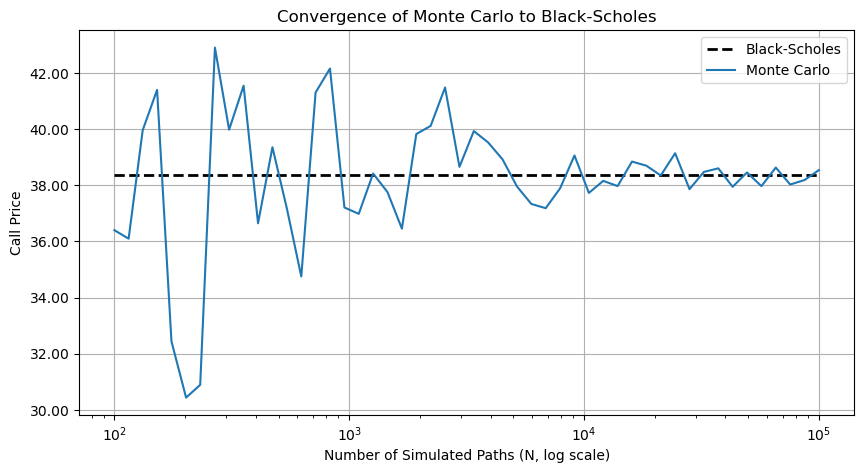

In [7]:
# compute price estimates and standard errors
conv_prices, std_errors, N_vals = compute_convergence_prices(pricer=mc_pricer)

plot_convergence(conv_prices, N_vals, call_price_bs)

The logarithmic scale highlights the greater variability of the Monte Carlo estimates at smaller $N$, reflecting higher random sampling error. This variability is quantified by the standard error (SE):

$$
SE = \frac{\hat\sigma}{\sqrt{N}},
$$

where $\hat\sigma$ is the sample standard deviation of the discounted payoffs.

The plot below shows the standard error (SE) of the Monte Carlo price estimates across the same range of $N$ values used in the convergence plot.

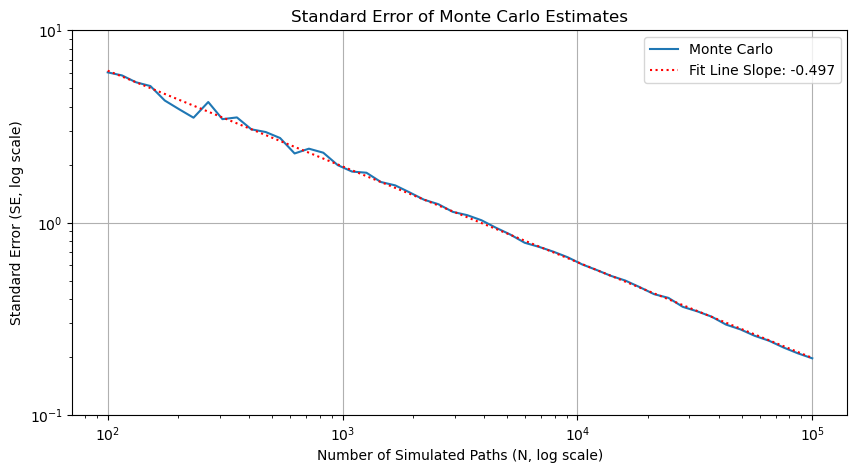

In [8]:
plot_standard_error(std_errors, N_vals)

The log–log plot shows that the standard error decreases linearly with $N$ on a logarithmic scale, with a slope of approximately $-\frac{1}{2}$. This is consistent with the theoretical convergence rate $SE \propto 1/\sqrt{N}$.

The final Monte Carlo price estimate from the convergence plot ($N=100000$) is shown alongside the earlier result for $N=1000$ to highlight the increase in accuracy.

In [9]:
print(f'Black-Scholes Benchmark:    {call_price_bs:.2f}')
print(f'Monte Carlo (N=1000):       {call_price_mc:.2f}')
print(f'Monte Carlo (N=100000):     {conv_prices[-1]:.2f}')

Black-Scholes Benchmark:    38.36
Monte Carlo (N=1000):       35.97
Monte Carlo (N=100000):     38.54


## Variance Reduction - Antithetic Variates

Monte Carlo accuracy improves with more simulations $N$ but this also increases computational cost. The antithetic variates method is a form of variance reduction that increases precision without increasing $N$ by exploiting symmetry in the random draws $Z$. This technique halves the number of independent random draws $Z$ and each random draw $Z$ is paired with its opposite $-Z$. This results in negatively correlated payoffs, which when averaged cancel out part of the random noise, reducing the variance of the estimate.

In [10]:
class AntitheticMonteCarloPricer(MonteCarloPricer):
    def call_price_european(self, num_simulations):
        # ensure N is even to give M = N/2 independent draws of Z
        if num_simulations % 2 == 1:
            num_simulations += 1
        M = num_simulations // 2

        drift = (self.r - 0.5 * self.sigma ** 2) * self.T
        vol = self.sigma * np.sqrt(self.T)

        # generate M random shocks and reuse Z with opposite signs
        Z = rng.standard_normal(M)
        plus = self.S * np.exp(drift + vol * Z)
        minus = self.S * np.exp(drift - vol * Z)

        # compute payoffs separately for +Z/-Z then average
        payoff_plus = np.maximum(plus - self.K, 0)
        payoff_minus = np.maximum(minus - self.K, 0)
        payoff = (payoff_plus + payoff_minus) / 2

        # discount to present value and compute price and standard error
        discounted = np.exp(-self.r * self.T) * payoff
        price = discounted.mean()
        se = discounted.std(ddof=1) / np.sqrt(M)

        return price, se

The standard error (SE) is compared between the standard Monte Carlo and antithetic versions across a range of $N$ values to illustrate the reduction in variance.

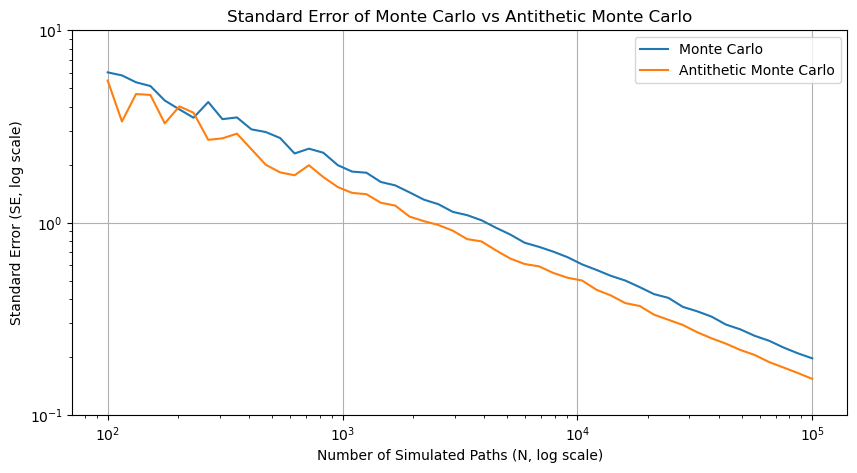

In [11]:
# create antithetic MC pricer
anti_mc_pricer = AntitheticMonteCarloPricer(S0, K, r, sigma, T)

# compute price estimates and standard errors
conv_prices_anti, std_errors_anti, N_vals_anti = compute_convergence_prices(pricer=anti_mc_pricer)

plot_standard_error_comparison(std_errors, std_errors_anti, N_vals)

The antithetic variates method consistently produces lower standard error for the same number of simulations $N$, demonstrating its effectiveness in reducing variance.

## Exotic Options

Unlike Black-Scholes, the Monte Carlo method simulates the entire stock price path over time, making it especially useful for pricing exotic options such as Asian, Barrier and Lookback options. As an example, a Barrier option is priced using the standard Monte Carlo pricer. Specifically, an up-and-out call option is considered, which becomes worthless if the stock price reaches or exceeds a barrier $B$ at any point before maturity $T$.

The payoff for an up-and-out call on path $i$ is given by

$$
\text{Payoff}_i =
\begin{cases}
\max(S_T^{(i)} - K, 0), & \text{if } S_t^{(i)} < B \text{ for all } t \in [0, T], \\
0, & \text{if } S_t^{(i)} \ge B \text{ for any } t \in [0, T].
\end{cases}
$$

In [12]:
class ExoticMonteCarloPricer(MonteCarloPricer):
    def up_and_out_call(self, paths, barrier):
        hit = (paths >= barrier).any(axis=0)            # true if path crossed barrier
        ST = paths[-1]                                  # terminal price
        payoff_plain = np.maximum(ST - self.K, 0)       # plain european call payoff
        payoff = np.where(hit, 0, payoff_plain)         # zero if barrier crossed or plain european payoff

        discounted = np.exp(-self.r * self.T) * payoff
        price = discounted.mean()
        N = paths.shape[1]
        se = discounted.std(ddof=1) / np.sqrt(N)

        return price, se, hit

Price paths are simulated for an up-and-out barrier option with $B=320$, using only $N=10$ paths for visual clarity and 100 time steps. The number of time steps controls how finely the price path is discretised. Increasing the number of steps can capture barrier crossings that might otherwise be missed. Here, 100 steps are used for simplicity.

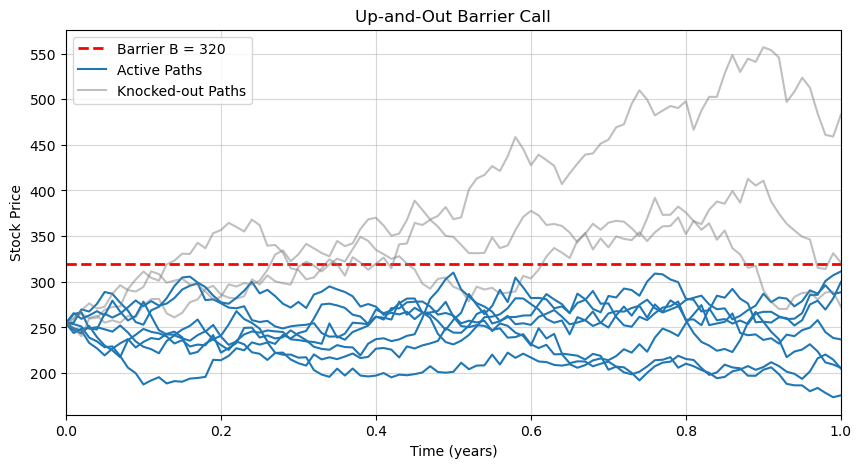

In [13]:
# create exotic MC pricer
exotic_pricer = ExoticMonteCarloPricer(S0, K, r, sigma, T)

# define barrier
barrier = 320

# evaluate up-and-out call and identify knocked out paths
paths, time = exotic_pricer.generate_price_paths(num_simulations=10, num_steps=100)
call_price_barrier, _, hit = exotic_pricer.up_and_out_call(paths, barrier)

plot_up_and_out_call(paths, time, hit, barrier)

The plot shows the paths that cross the barrier are knocked out, while the remaining ones continue to maturity, highlighting how Monte Carlo simulation captures path-dependent behaviour.